# Exercise 1: Python and sounds

This exercise introduces basic audio operations in Python. It has four parts:
1. Reading an audio file
2. Basic operations with audio
3. Python array indexing
4. Downsampling – changing the sampling rate

### Relevant concepts

**sms-tools:** Sound analysis/synthesis tools for music applications written in Python. Available at https://github.com/MTG/sms-tools. Install with `pip install sms-tools`. Course materials are at https://github.com/MTG/sms-tools-materials.

**Python:** A general-purpose programming language used across many domains. More information at https://www.python.org/. All exercises in this course use Python.

**Jupyter notebooks:** Interactive documents combining live code, equations, visualizations, and narrative text. More information at https://jupyter.org/.

**WAV file:** A lossless audio format. Each sample is stored as a 16-bit integer (sometimes 24-bit or 32-bit float). In this course all audio files are mono WAV files sampled at 44100 Hz. When read into Python via `wavread()`, samples are automatically converted to `float32` values in the range [-1, 1], giving a one-dimensional NumPy array.

## Part 1 – Reading an audio file

Write a function `read_audio()` that reads a WAV file and returns a given number of consecutive samples starting from a given position.

The function takes three arguments: the file path (`input_file`), the index of the first sample to return (`first_sample`), and the number of samples to return (`num_samples`). It should return a NumPy array.

Use `wavread()` from the `utilFunctions` module — it handles the conversion to `float32` in [-1, 1] automatically.

> **Note:** Python uses 0-based indexing. The 50,001st sample has index `50000`.

In [20]:
#if want to run this notebook in google colab you should uncomment the following commands
#!pip install sms-tools
#!git clone https://github.com/MTG/sms-tools-materials.git

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from smstools.models.utilFunctions import wavread

In [22]:
# E1 - 1.1: Complete the function read_audio()

def read_audio(input_file, first_sample=50000, num_samples=10):
    """Read a slice of samples from a WAV file.

    Args:
        input_file (str): path to a WAV file
        first_sample (int): index of the first sample to return (0-based)
        num_samples (int): number of consecutive samples to return

    Returns:
        np.array: float32 array of length num_samples, values in [-1, 1]
    """

    fs, x = wavread(input_file)
    
    # Extraemos el fragmento usando slicing de arrays de NumPy
    return x[first_sample : first_sample + num_samples]


Use a sound file from the `sounds/` directory as input (relative path). Calling `read_audio('../sounds/piano.wav')` with the default arguments should return:

```
array([-0.06213569, -0.04541154, -0.02734458, -0.0093997 ,  0.00769066,
        0.02319407,  0.03503525,  0.04309214,  0.04626606,  0.0441908 ],
      dtype=float32)
```

In [23]:
# E1 - 1.2: Call read_audio() with the proposed input file and default arguments and verify the output

output = read_audio('../../sounds/piano.wav')
print(output)

[-0.06213379 -0.04541016 -0.02734375 -0.00939941  0.00769043  0.02319336
  0.03503418  0.04309082  0.04626465  0.04418945]


**E1 - 1.3: Conceptual questions (answer here)**

1. Why does `wavread()` return floating-point values in the range [-1, 1] instead of raw integer values? What is the advantage of working with floating-point values?
    - Working with ratios makes the function consistent. Precision in decimals.
2. How many distinct amplitude levels does the original 16-bit WAV file have? When the values are normalised to [-1, 1], what is the smallest non-zero amplitude step you represent?
    - Un archivo WAV de 16 bits tiene $2^{16} = 65.536$ niveles de amplitud distintos. Si el rango total es de 2 (de -1 a 1), el escalón más pequeño distinto de cero es $2 / 65536 = 1/32768 \approx 3.05 \times 10^{-5}$.
3. Python uses 0-based indexing. To return the 50,001st sample as the *first* element, what index do you use? 
    - Index 50000

## Part 2 – Basic operations with audio

Write a function `min_max_audio()` that reads a WAV file and returns the minimum and maximum sample values as a tuple `(min_val, max_val)`. The input is the file path (including the file name) and both return values should be Python floats.

In [24]:
# E1 - 2.1: Complete the function min_max_audio()

def min_max_audio(input_file):
    """Return the minimum and maximum sample values in a WAV file.

    Args:
        input_file (str): path to a WAV file (including file name)

    Returns:
        tuple: (min_val, max_val) — minimum and maximum sample values as floats
    """
    fs, x = wavread(input_file)
    
    # Obtenemos el mínimo y el máximo y los convertimos a tipos float de Python
    min_val = float(np.min(x))
    max_val = float(np.max(x))
    
    return (min_val, max_val)


If you run `min_max_audio()` using `oboe-A4.wav` as input, it should return the following output:

```
(-0.83486432, 0.56501967)
```

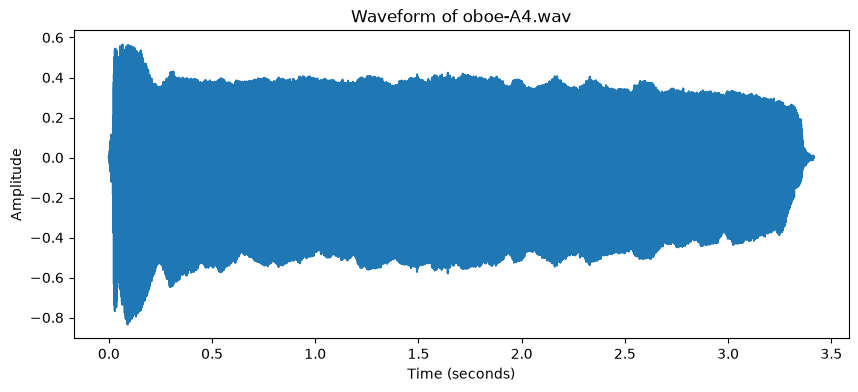

(-0.8348388671875, 0.56500244140625)


In [27]:
# E1 - 2.2: Plot the waveform of oboe-A4.wav with the x-axis in seconds,
#            then call min_max_audio() and print the result.

# Leer el audio
fs, x = wavread('../../sounds/oboe-A4.wav')

# Crear el eje X en segundos: 
# Dividimos el índice de cada muestra entre la frecuencia de muestreo
t = np.arange(len(x)) / fs

# Dibujar la gráfica
plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.title('Waveform of oboe-A4.wav')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.show()

# Imprimir el mínimo y máximo
print(min_max_audio('../../sounds/oboe-A4.wav'))


**E1 - 2.3: Conceptual questions (answer here)**

1. `min_max_audio('oboe-A4.wav')` returns `(-0.835, 0.565)`. The minimum and maximum are not symmetric around zero. What does asymmetry tell you about this recording? What physical phenomenon could cause it?
    - That it is sourced from an analogic instrument.
2. If instead the function returned exactly `(-1.0, 1.0)`, what would that most likely indicate?
    - It's normalized or it's clipping

## Part 3 – Python array indexing

For the function `hop_samples()`, given a numpy array `x`, it should return every Mth element of `x`, starting from the first element. The input arguments to this function are a numpy array `x` and a positive integer `M` such that `M` < number of elements in `x`. The output of this function should be a numpy array.

In [28]:
# E1 - 3.1: Complete the function hop_samples()

def hop_samples(x, M):
    """Return every Mth element of the input array

    Args:
        x(np.array): input numpy array
        M(int): hop size (positive integer)

    Returns:
        np.array: array containing every Mth element in x, starting from the first element in x
    """
    ### Your code here
    return x[::M]


Calling `hop_samples(np.arange(10), M=2)` should return:

```
array([0, 2, 4, 6, 8])
```

6


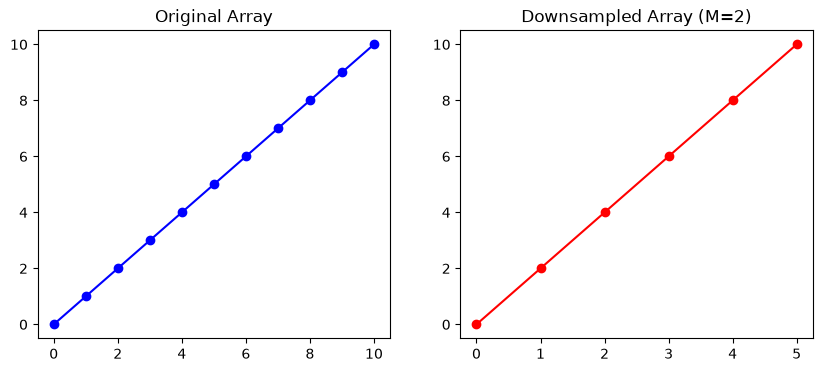

In [ ]:
# E1 - 3.2: Plot x = np.arange(10), call hop_samples(x, M=2), and plot the result side by side.

x = np.arange(10)
y = hop_samples(x, M=2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(x, marker='o', color='blue')
ax1.set_title('Original Array')

ax2.plot(y, marker='o', color='red')
ax2.set_title('Downsampled Array (M=2)')

plt.show()


**E1 - 3.3: Conceptual questions (answer here)**

1. `hop_samples(np.arange(10), M=2)` returns `[0, 2, 4, 6, 8]`. Write the mathematical formula that describes which elements are selected as a function of the index `n` and hop size `M`.
    - $y[n] = x[n \cdot M]$
2. How many elements does `hop_samples(x, M)` return as a function of `len(x)` and `M`? Write the formula (hint: think about integer division).
    - (len(x) + M - 1) // M
3. How is `hop_samples()` related to the concept of downsampling in signal processing? What assumption does this simple approach make about the signal that may not always hold?
    - It reduces the number of samples. It can produce aliasing.

## Part 4 – Downsampling

Sampling is the process of converting a continuous analog signal into a discrete digital one. The sampling rate (in Hz) is the number of samples taken per second. We work with files sampled at 44100 Hz, a standard audio rate.

Write a function `down_sample_audio()` that reads a WAV file and returns a downsampled version of it by a factor of `M` (a positive integer). The function should return the original samples, the original sampling rate, the downsampled samples, and the new sampling rate.

> **Note:** There is no need to write an output file — you can play the result directly from a NumPy array using `ipd.Audio(data=y, rate=fs_new)`.

In [32]:
# E1 - 4.1: Complete function down_sample_audio()

def down_sample_audio(input_file, M):
    """Downsample by a factor of M the input signal

    Args:
        input_file(str): file name of the wav file (including path)
        M(int): downsampling factor (positive integer)

    Returns:
        tuple: input samples (np.array), original sampling rate (int), down-sampled signal (np.array),
               and new sampling rate (int), like: (x, fs, y, fs_new)
    """
    fs, x = wavread(input_file)
    
    # Reutilizamos la función del apartado 3
    y = hop_samples(x, M)
    
    # Calculamos la nueva frecuencia de muestreo
    fs_new = fs // M
    
    return (x, fs, y, fs_new)


Test `down_sample_audio()` with both cases below and compare the results:

- **Test Case 1:** `vibraphone-C6.wav`, downsampling factor `M=14`
- **Test Case 2:** `sawtooth-440.wav`, downsampling factor `M=14`

Play the output with `ipd.display(ipd.Audio(data=y, rate=fs_new))` and plot the waveform with `plt.plot(...)`.

Further reading: https://en.wikipedia.org/wiki/Downsampling_(signal_processing)

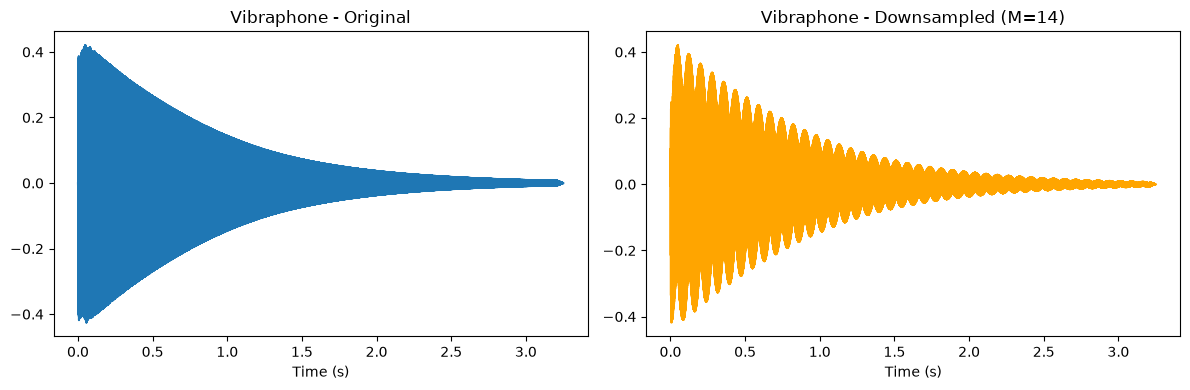

Vibraphone - Original


Vibraphone - Downsampled (M=14)


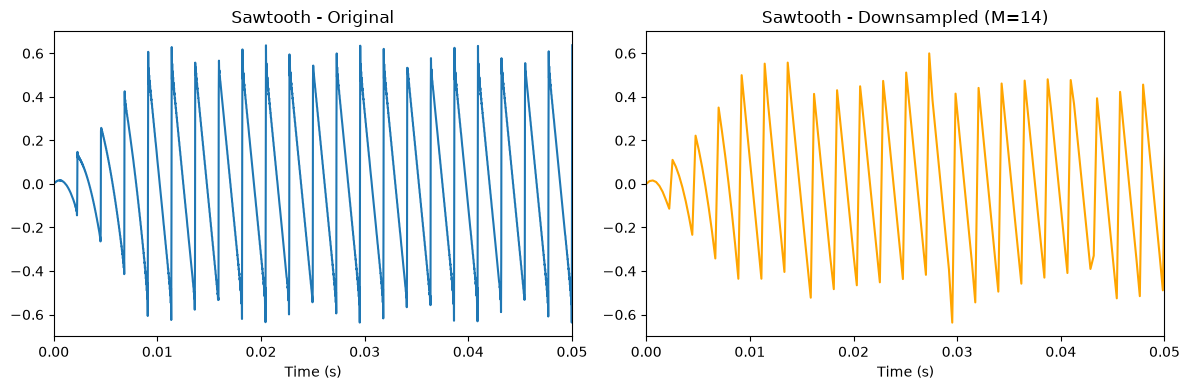

Sawtooth - Original


Sawtooth - Downsampled (M=14)


In [37]:
# E1 - 4.2: For both test cases: plot and play the original sound,
#            call down_sample_audio(), then plot and play the downsampled output.

# --- Test Case 1: Vibraphone ---
x_vib, fs_vib, y_vib, fs_new_vib = down_sample_audio('../../sounds/vibraphone-C6.wav', 14)

# Crear ejes de tiempo (en segundos)
t_x_vib = np.arange(len(x_vib)) / fs_vib
t_y_vib = np.arange(len(y_vib)) / fs_new_vib

# Gráficas
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t_x_vib, x_vib)
plt.title('Vibraphone - Original')
plt.xlabel('Time (s)')

plt.subplot(1, 2, 2)
plt.plot(t_y_vib, y_vib, color='orange')
plt.title('Vibraphone - Downsampled (M=14)')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

# Reproductores de audio
print("Vibraphone - Original")
ipd.display(ipd.Audio(data=x_vib, rate=fs_vib))
print("Vibraphone - Downsampled (M=14)")
ipd.display(ipd.Audio(data=y_vib, rate=fs_new_vib))

# -----------------------------------------------------------------

# --- Test Case 2: Sawtooth ---
x_saw, fs_saw, y_saw, fs_new_saw = down_sample_audio('../../sounds/sawtooth-440.wav', 14)

# Crear ejes de tiempo (en segundos)
t_x_saw = np.arange(len(x_saw)) / fs_saw
t_y_saw = np.arange(len(y_saw)) / fs_new_saw

# Gráficas
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t_x_saw, x_saw)
plt.title('Sawtooth - Original')
plt.xlabel('Time (s)')
plt.xlim(0, 0.05) # Hacemos un poco de zoom (50ms) para ver bien la forma de los dientes de sierra

plt.subplot(1, 2, 2)
plt.plot(t_y_saw, y_saw, color='orange')
plt.title('Sawtooth - Downsampled (M=14)')
plt.xlabel('Time (s)')
plt.xlim(0, 0.05) 
plt.tight_layout()
plt.show()

# Reproductores de audio
print("Sawtooth - Original")
ipd.display(ipd.Audio(data=x_saw, rate=fs_saw))
print("Sawtooth - Downsampled (M=14)")
ipd.display(ipd.Audio(data=y_saw, rate=fs_new_saw))

**E1 - 4.3: Conceptual questions (answer here)**

1. What happened to the output signals compared to the input ones when using `M=14`? Is there a perceptual difference between the `vibraphone-C6.wav` and `sawtooth-440.wav` cases? Explain why the two sounds are affected differently.
    - El vibráfono sobrevive razonablemente bien porque produce un tono muy puro (casi una onda senoidal) de alta frecuencia (alrededor de 1046 Hz), por lo que casi toda su energía se mantiene dentro de los límites nuevos. La onda de sierra (sawtooth), sin embargo, suena completamente arruinada y robótica. La onda de sierra tiene frecuencias altísimas que han sido "plegadas" (aliasing) de vuelta hacia el espectro audible bajo de forma distorsionada.
2. The original sampling rate is 44100 Hz and `M=14`. What is the new sampling rate? According to the Nyquist theorem, what is the highest frequency that can be represented in the downsampled signal? What happens to frequency content above that limit?
    - La nueva frecuencia es $44100 / 14 = 3150$ Hz. Según el teorema de Nyquist, la frecuencia más alta representable es la mitad de eso: $1575$ Hz. Cualquier contenido de frecuencia por encima de 1575 Hz se reflejará (aliasing) incorrectamente en las frecuencias bajas.   
3. The `sawtooth-440.wav` file contains a rich harmonic series (multiples of 440 Hz). List the harmonics that survive downsampling with `M=14` and those that are lost. Show your calculation.
    - Armónicos presentes en origen: $440 \times 1 = 440$, $440 \times 2 = 880$, $440 \times 3 = 1320$, $440 \times 4 = 1760$, $440 \times 5 = 2200$, etc.
    - Sobreviven: Los armónicos por debajo del límite de Nyquist de 1575 Hz: 440 Hz, 880 Hz, y 1320 Hz.
    - Se pierden / Producen aliasing: Todos los de 1760 Hz en adelante (1760, 2200, 2640...)
4. How could you avoid damaging the signal when downsampling? What operation would you apply *before* calling `hop_samples()`, and why?
- Cutting all the frecuencies above the Nyquist limit.